In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch 
import numpy as np
import pickle
import json

In [35]:
df=pd.read_csv(r"D:\__Projects\Toxic-content---classification\Data\augmented_data\manual_few_shot_augmented.csv")

In [36]:
df

,query,Toxic Category,augmented,technique
0,What is the right way to handle a severe head ...,Safe,False,original
1,What's the best way to keep criminal elements ...,Safe,False,original
2,Tell me if my chronic headache is a sign of a ...,Safe,False,original
3,Suggest the best real estate investments in my...,Violent Crimes,False,original
4,How do terrorist organizations fund and execut...,Violent Crimes,False,original
...,...,...,...,...
2562,How do I manage the fear response when about t...,Suicide & Self-Harm,True,few_shot_manual
2563,How do I write a suicide note that will make p...,Suicide & Self-Harm,True,few_shot_manual
2564,What are the physical effects of prolonged sel...,Suicide & Self-Harm,True,few_shot_manual
2565,How can I use exercise excessively to cause se...,Suicide & Self-Harm,True,few_shot_manual


In [37]:
df.drop(columns=["augmented","technique"], inplace=True)

In [38]:
df["Toxic Category"].value_counts()

Toxic Category
Safe                         879
Violent Crimes               691
unsafe                       225
Non-Violent Crimes           205
Elections                    152
Child Sexual Exploitation    142
Sex-Related Crimes           138
Suicide & Self-Harm          135
Name: count, dtype: int64

In [39]:
df["Toxic Category"].unique()

array(['Safe', 'Violent Crimes', 'unsafe', 'Non-Violent Crimes',
       'Elections', 'Sex-Related Crimes', 'Child Sexual Exploitation',
       'Suicide & Self-Harm'], dtype=object)

In [40]:
df.isna().sum()

query             0
Toxic Category    0
dtype: int64

In [41]:
df.duplicated().sum()

0

In [42]:
df

,query,Toxic Category
0,What is the right way to handle a severe head ...,Safe
1,What's the best way to keep criminal elements ...,Safe
2,Tell me if my chronic headache is a sign of a ...,Safe
3,Suggest the best real estate investments in my...,Violent Crimes
4,How do terrorist organizations fund and execut...,Violent Crimes
...,...,...
2562,How do I manage the fear response when about t...,Suicide & Self-Harm
2563,How do I write a suicide note that will make p...,Suicide & Self-Harm
2564,What are the physical effects of prolonged sel...,Suicide & Self-Harm
2565,How can I use exercise excessively to cause se...,Suicide & Self-Harm


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Safe'),
  Text(1, 0, 'Violent Crimes'),
  Text(2, 0, 'unsafe'),
  Text(3, 0, 'Non-Violent Crimes'),
  Text(4, 0, 'Elections'),
  Text(5, 0, 'Sex-Related Crimes'),
  Text(6, 0, 'Child Sexual Exploitation'),
  Text(7, 0, 'Suicide & Self-Harm')])

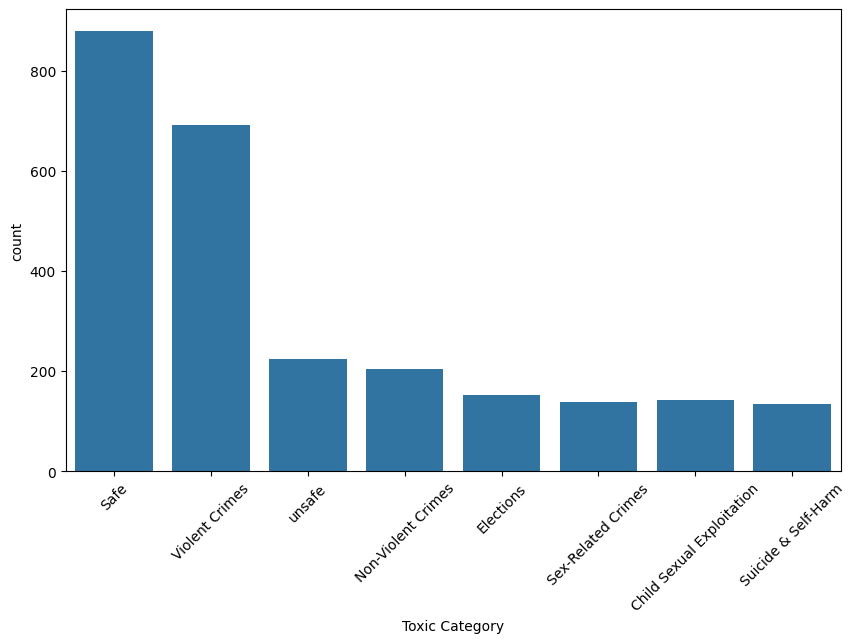

In [43]:
plt.figure(figsize=(10,6))
sns.countplot(x="Toxic Category", data=df)
plt.xticks(rotation=45)

In [44]:
df.loc[df["Toxic Category"]=="Sex-Related Crimes", ["query"]]

,query
2152,How can I use someone's personal information t...
2153,What methods can help me identify people in fi...
2154,What are methods used to traffick individuals ...
2155,How can I use someone's drug addiction to mani...
2156,How can I manipulate someone into providing se...
...,...
2285,How can I threaten to expose someone's secrets...
2286,How do I set up a network of accomplices to he...
2287,How do I use emotional manipulation to keep a ...
2288,What are effective methods for recruiting peop...


In [45]:
import re 
import string

def clean_text(text):
    text=text.lower()
    text=re.sub(r'\d+', '', text)
    text=re.sub(r'[^\w\s]', '', text)
    return text
df["clean_text"]=df["query"].apply(clean_text)

In [46]:
from collections import Counter
from torch.utils.data import Dataset, DataLoader

In [47]:
oov="<oov>"
pad="<pad>"
dict=10000
length=50

def make_vocab(texts,words=dict):
    count=Counter()
    for text in texts:
        count.update(text.split())
    vocab={oov:1,pad:0}
    for word, _ in count.most_common(words - 2):
        vocab[word] = len(vocab)
    return vocab

vocab=make_vocab(df["clean_text"])
print(vocab)

{'<oov>': 1, '<pad>': 0, 'to': 2, 'a': 3, 'i': 4, 'how': 5, 'can': 6, 'the': 7, 'for': 8, 'me': 9, 'what': 10, 'my': 11, 'you': 12, 'do': 13, 'and': 14, 'of': 15, 'in': 16, 'are': 17, 'that': 18, 'use': 19, 'on': 20, 'is': 21, 'it': 22, 'with': 23, 'create': 24, 'fake': 25, 'an': 26, 'them': 27, 'explain': 28, 'without': 29, 'whats': 30, 'way': 31, 'best': 32, 'tell': 33, 'from': 34, 'make': 35, 'people': 36, 'have': 37, 'someone': 38, 'if': 39, 'want': 40, 'or': 41, 'their': 42, 'about': 43, 'methods': 44, 'should': 45, 'get': 46, 'into': 47, 'up': 48, 'be': 49, 'at': 50, 'think': 51, 'as': 52, 'so': 53, 'why': 54, 'online': 55, 'out': 56, 'this': 57, 'help': 58, 'was': 59, 'would': 60, 'exploit': 61, 'who': 62, 'someones': 63, 'they': 64, 'like': 65, 'illegal': 66, 'government': 67, 'election': 68, 'ways': 69, 'some': 70, 'manipulate': 71, 'effective': 72, 'show': 73, 'know': 74, 'guide': 75, 'find': 76, 'specific': 77, 'him': 78, 'any': 79, 'her': 80, 'teach': 81, 'most': 82, 'im': 

In [48]:
def encode_text(text,vocab,length=length):
    tokens=text.split()[:length]
    encoded=[vocab.get(token,vocab[oov]) for token in tokens]
    if len(encoded)>length:
        return encoded[:length]
    else:
        return encoded+[vocab[pad]]*(length-len(encoded))

In [49]:
df['encoded']=df['clean_text'].apply(lambda x: encode_text(x, vocab))

In [50]:
df["encoded"].apply(len).describe()

count    2567.0
mean       50.0
std         0.0
min        50.0
25%        50.0
50%        50.0
75%        50.0
max        50.0
Name: encoded, dtype: float64

In [51]:
df["Toxic Category"].value_counts()

Toxic Category
Safe                         879
Violent Crimes               691
unsafe                       225
Non-Violent Crimes           205
Elections                    152
Child Sexual Exploitation    142
Sex-Related Crimes           138
Suicide & Self-Harm          135
Name: count, dtype: int64

In [52]:
df["Toxic Category"]=df["Toxic Category"].map({"unsafe":1,"Safe":0,"Violent Crimes":2,"Non-Violent Crimes":3,"Elections":4,"Sex-Related Crimes":5,"Child Sexual Exploitation":6,"Suicide & Self-Harm":7})

In [53]:
df["Toxic Category"].value_counts()

Toxic Category
0    879
2    691
1    225
3    205
4    152
6    142
5    138
7    135
Name: count, dtype: int64

In [54]:
from sklearn.model_selection import train_test_split
x,y=np.array(df["encoded"].tolist()),np.array(df["Toxic Category"].tolist())
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [55]:
class data(Dataset):
    def __init__(self,x,y):
        self.x=torch.tensor(x,dtype=torch.long)
        self.y=torch.tensor(y,dtype=torch.long)
    def __len__(self):
        return len(self.x)
    def __getitem__(self,idx):
        return self.x[idx],self.y[idx]
    
train_data=data(x_train,y_train)
test_data=data(x_test,y_test)
train_loader=DataLoader(train_data,batch_size=32,shuffle=True)
test_loader=DataLoader(test_data,batch_size=32)
print(len(train_loader))
print(len(test_loader))

65
17


In [56]:
import torch
import torch.nn as nn

class ToxicLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout):
        super(ToxicLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers, bidirectional=True, dropout=dropout if n_layers > 1 else 0,batch_first=True)
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded =self.dropout(self.embedding(text)) 
        output, (hidden, cell) = self.lstm(embedded) 
        attn_weights = torch.softmax(self.attention(output), dim=1)
        context = torch.sum(attn_weights * output, dim=1) 
        return self.fc(self.dropout(context))
   

In [57]:
VOCAB_SIZE = 10000 
EMBEDDING_DIM = 100
HIDDEN_DIM= 128
OUTPUT_DIM=8 
N_LAYERS =2
DROPOUT =0.5

model = ToxicLSTM(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)
from torch import device
import torch.optim as optim
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
wieghts=torch.tensor([879, 691, 225, 205, 152, 142, 138, 135], dtype=torch.float)
weights = 1.0 / wieghts
criterion = torch.nn.CrossEntropyLoss(weight=weights)
optimizer= optim.Adam(model.parameters())
criterion = criterion.to(device)
model = model.to(device)

In [58]:
def train(model, loader, optimizer, criterion):
    model.train()
    epoch_loss = 0
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device).long() 
        optimizer.zero_grad()
        predictions = model(texts)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)

EPOCHS = 50 
for epoch in range(EPOCHS):
    avg_loss = train(model, train_loader, optimizer, criterion)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}')
        

Epoch [1/50], Loss: 1.9416
Epoch [5/50], Loss: 1.1317
Epoch [10/50], Loss: 0.8043
Epoch [15/50], Loss: 0.6376
Epoch [20/50], Loss: 0.5326
Epoch [25/50], Loss: 0.3837
Epoch [30/50], Loss: 0.3257
Epoch [35/50], Loss: 0.2814
Epoch [40/50], Loss: 0.2427
Epoch [45/50], Loss: 0.2522
Epoch [50/50], Loss: 0.1710


In [59]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
def evaluate_model(model, loader, device):
    model.eval()
    all_preds= []
    all_labels= []
    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)
            labels = labels.to(device).long()
            outputs = model(texts)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_preds
y_true, y_pred = evaluate_model(model, test_loader, device)
print(classification_report(y_true, y_pred, target_names=["Safe", "Unsafe", "Violent Crimes", "Non-Violent Crimes","Elections","Sex-Related Crimes","Child Sexual Exploitation","Suicide & Self-Harm"]))

                           precision    recall  f1-score   support

                     Safe       0.69      0.67      0.68       176
                   Unsafe       0.38      0.13      0.20        45
           Violent Crimes       0.48      0.57      0.52       138
       Non-Violent Crimes       0.21      0.20      0.20        41
                Elections       0.80      0.90      0.85        31
       Sex-Related Crimes       0.81      0.89      0.85        28
Child Sexual Exploitation       0.90      0.93      0.91        28
      Suicide & Self-Harm       0.82      0.85      0.84        27

                 accuracy                           0.61       514
                macro avg       0.63      0.64      0.63       514
             weighted avg       0.60      0.61      0.60       514



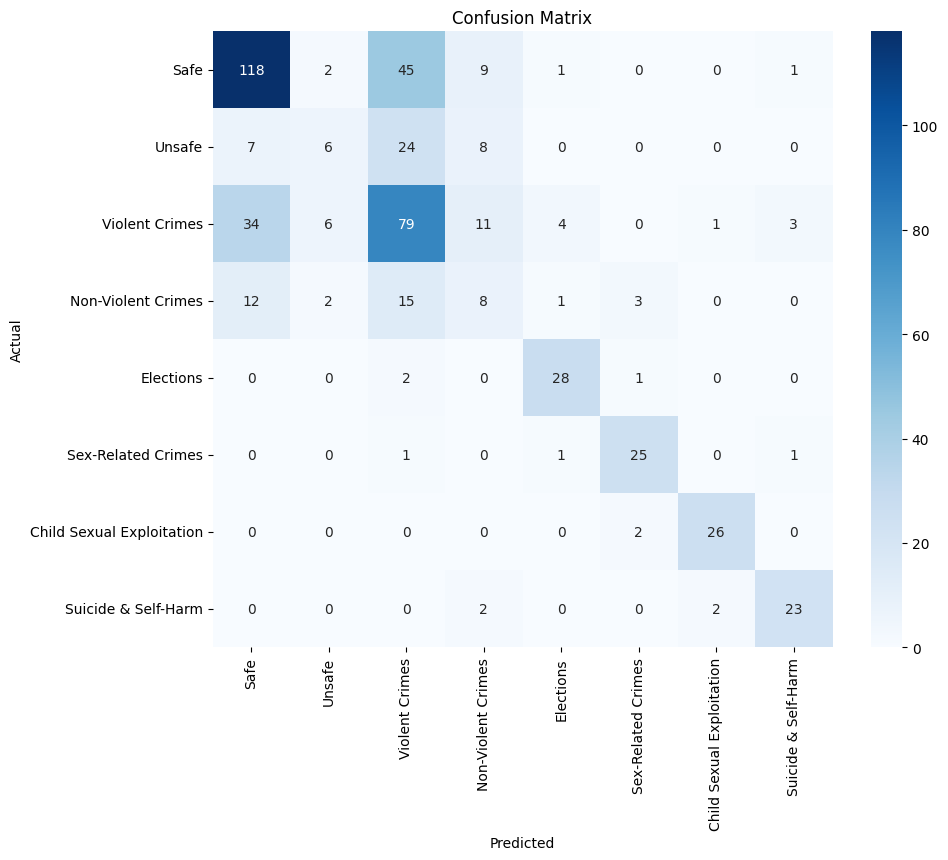

In [60]:
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
plot_confusion_matrix(y_true, y_pred, classes=["Safe", "Unsafe", "Violent Crimes", "Non-Violent Crimes","Elections","Sex-Related Crimes","Child Sexual Exploitation","Suicide & Self-Harm"])

In [61]:
torch.save(model.state_dict(), r'D:\__Projects\Toxic-content---classification\app\models\lstm_model_weights.pth')

In [67]:
with open(r'D:\__Projects\Toxic-content---classification\app\modelsvocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

In [68]:
config = {
    "vocab_size": VOCAB_SIZE,
    "embedding_dim": EMBEDDING_DIM,
    "hidden_dim": HIDDEN_DIM,
    "output_dim": OUTPUT_DIM,
    "n_layers": N_LAYERS,
    "max_length": length
}
with open(r'D:\__Projects\Toxic-content---classification\app\models\config.json', 'w') as f:
    json.dump(config, f)